## Notebook for data examination after clustering

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import pandas as pd
from pandas.plotting import scatter_matrix
import seaborn as sns
import os

from tqdm import tqdm

import hdbscan

from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score, silhouette_score#, calinski_harabasz_score, davies_bouldin_score

from sklearn.manifold import TSNE

from sklearn.cluster import DBSCAN
from sklearn.cluster import SpectralClustering
from sklearn.cluster import AgglomerativeClustering

import plotly.express as px
import plotly.graph_objects as go

# interactive matplotlib backend_inline
#%matplotlib widget

In [2]:
# import the merged data file
merged_df = pd.read_csv('fusion_results_merged_with_clusters.csv.gzip', compression='gzip', sep=',', header=0, dtype={'# sample': str, 'Depth': str})
merged_df.head()

,Mg,Al,Si,K,Ca,Ti,Mn,Fe,Rb,Sr,...,Mn mole fraction,Fe mole fraction,Rb mole fraction,Sr mole fraction,Zr mole fraction,Ba mole fraction,La mole fraction,Ce mole fraction,U mole fraction,Agglomerative Cluster
0,0.0,0.0000,0.0,0.0,0.0,0.000,0.0,4364.6397,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
1,0.0,3359.1233,0.0,0.0,0.0,0.000,0.0,0.0000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.0,0.0000,0.0,0.0,0.0,0.000,0.0,2334.2033,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
3,0.0,0.0000,0.0,0.0,0.0,48093.213,0.0,0.0000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,0.0,0.0000,0.0,0.0,0.0,0.000,0.0,0.0000,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0


In [3]:
# Calculate the mean and standard deviation for each cluster
def calculate_cluster_stats(dataframe, cluster_col=['Agglomerative Cluster']):
    numeric_df = dataframe.select_dtypes(include='number').copy()
    numeric_df[cluster_col[0]] = dataframe[cluster_col[0]].values
    stats = numeric_df.groupby(cluster_col).agg(['mean', 'std'])
    return stats

# Compute stats for clusters and for samples
cluster_stats = calculate_cluster_stats(merged_df, cluster_col=['Agglomerative Cluster'])
sample_stats = calculate_cluster_stats(merged_df, cluster_col=['# sample'])

# Compute cluster sizes
size_clusters = merged_df['Agglomerative Cluster'].value_counts()
size_clusters.sort_index(inplace=True)

size_clusters_df = pd.DataFrame(size_clusters).reset_index()
size_clusters_df.columns = ['Agglomerative Cluster', 'Number']
size_clusters_df['Fraction'] = size_clusters_df['Number'] / size_clusters_df['Number'].sum() * 100

# Compute total mass per cluster and merge it
total_mass = merged_df.groupby('Agglomerative Cluster')['Sum'].sum().reset_index()
size_clusters_df = pd.merge(size_clusters_df, total_mass, on='Agglomerative Cluster')
size_clusters_df.rename(columns={'Sum': 'Total mass'}, inplace=True)


# Create a sentence column for plotting or reporting
size_clusters_df['Sentence'] = size_clusters_df.apply(
    lambda row: f"Cluster {int(row['Agglomerative Cluster'])}\nn = {int(row['Number'])}\n({row['Fraction']:.1f}%)",
    axis=1
)

# Preview the result
size_clusters_df.head()

,Agglomerative Cluster,Number,Fraction,Total mass,Sentence
0,0,32334,7.775344,2.537724e+08,Cluster 0\nn = 32334\n(7.8%)
1,1,40844,9.821740,6.053243e+08,Cluster 1\nn = 40844\n(9.8%)
2,2,37855,9.102976,6.730776e+09,Cluster 2\nn = 37855\n(9.1%)
3,3,21810,5.244642,1.827007e+08,Cluster 3\nn = 21810\n(5.2%)
4,4,203471,48.928588,1.097380e+09,Cluster 4\nn = 203471\n(48.9%)


In [4]:
# read the elements.txt file to save the elements
df_elements = pd.read_csv('Add_data/elements.txt', sep='\t', header=None, names=['Element'])
# Convert the elements DataFrame to a list
elements = df_elements['Element'].tolist()

In [5]:
# create a df for counts of elements in each cluster
def count_elements_in_clusters(dataframe, cluster_col='Agglomerative Cluster', elements_list=elements):
    counts = {}
    for element in elements_list:
        counts[element] = merged_df[element].groupby(merged_df['Agglomerative Cluster']).apply(lambda x: (x != 0).sum()).values
    pd.DataFrame(counts).fillna(0).astype(int)
    # add the cluster column as index
    counts[cluster_col] = np.sort(merged_df[cluster_col].unique())
    counts = pd.DataFrame(counts).set_index(cluster_col)
    # add " mole fraction" to each column name
    counts.columns = [f"{col} mole fraction" for col in counts.columns if col != cluster_col]
    return pd.DataFrame(counts).fillna(0).astype(int)

# Count elements in clusters
element_counts = count_elements_in_clusters(merged_df, cluster_col='Agglomerative Cluster', elements_list=elements)
element_counts

,Mg mole fraction,Al mole fraction,Si mole fraction,K mole fraction,Ca mole fraction,Ti mole fraction,Mn mole fraction,Fe mole fraction,Rb mole fraction,Sr mole fraction,Zr mole fraction,Ba mole fraction,La mole fraction,Ce mole fraction,U mole fraction
Agglomerative Cluster,,,,,,,,,,,,,,,
0,4502,243,56,8472,7567,3761,1558,8464,634,1037,1538,1873,2688,1638,6
1,7,40842,139,6700,3979,1704,460,25860,15,309,96,1503,157,192,1
2,3505,34570,37350,21248,11985,11019,6417,33808,1771,3126,638,10281,405,1268,433
3,0,39,10,22,27,21810,13,1238,0,4,202,42,19,37,1
4,4,243,64,882,406,1923,1596,203471,13,111,146,574,214,277,1
5,65,2020,79539,8479,1333,2662,1576,24531,1125,136,60,1784,40,335,2


In [6]:
# Select column "mass fraction"
mole_fraction_cols = [col for col in cluster_stats.columns if col[0].endswith('mole fraction')]

# Extract mean & std
means = cluster_stats[mole_fraction_cols].xs('mean', axis=1, level=1) * 100
stds = cluster_stats[mole_fraction_cols].xs('std', axis=1, level=1) * 100

# Create an annotation matrix
annot = means.round(1).astype(str) + " ± " + stds.round(1).astype(str) + "\n(n = " + element_counts.astype(str) + ")"

# Display the annotation matrix
annot

,Mg mole fraction,Al mole fraction,Si mole fraction,K mole fraction,Ca mole fraction,Ti mole fraction,Mn mole fraction,Fe mole fraction,Rb mole fraction,Sr mole fraction,Zr mole fraction,Ba mole fraction,La mole fraction,Ce mole fraction,U mole fraction
Agglomerative Cluster,,,,,,,,,,,,,,,
0,13.9 ± 34.6\n(n = 4502),0.2 ± 2.3\n(n = 243),0.0 ± 0.8\n(n = 56),24.1 ± 41.4\n(n = 8472),17.7 ± 34.4\n(n = 7567),5.1 ± 15.3\n(n = 3761),3.6 ± 18.7\n(n = 1558),11.4 ± 21.3\n(n = 8464),2.0 ± 13.8\n(n = 634),2.8 ± 16.2\n(n = 1037),4.4 ± 20.5\n(n = 1538),3.9 ± 19.1\n(n = 1873),7.1 ± 25.0\n(n = 2688),3.9 ± 18.3\n(n = 1638),0.0 ± 0.5\n(n = 6)
1,0.0 ± 0.1\n(n = 7),81.4 ± 17.3\n(n = 40842),0.1 ± 1.0\n(n = 139),2.2 ± 6.0\n(n = 6700),2.3 ± 7.7\n(n = 3979),0.3 ± 2.3\n(n = 1704),0.0 ± 0.2\n(n = 460),13.7 ± 15.6\n(n = 25860),0.0 ± 0.0\n(n = 15),0.0 ± 0.4\n(n = 309),0.0 ± 0.6\n(n = 96),0.0 ± 0.1\n(n = 1503),0.0 ± 0.1\n(n = 157),0.0 ± 0.3\n(n = 192),0.0 ± 0.2\n(n = 1)
2,2.3 ± 9.0\n(n = 3505),33.9 ± 16.5\n(n = 34570),45.7 ± 14.9\n(n = 37350),3.0 ± 3.9\n(n = 21248),3.3 ± 6.6\n(n = 11985),0.7 ± 2.7\n(n = 11019),0.1 ± 0.3\n(n = 6417),10.1 ± 10.9\n(n = 33808),0.0 ± 0.0\n(n = 1771),0.0 ± 0.0\n(n = 3126),0.0 ± 0.2\n(n = 638),0.0 ± 0.1\n(n = 10281),0.0 ± 0.0\n(n = 405),0.0 ± 0.1\n(n = 1268),1.0 ± 9.6\n(n = 433)
3,0.0 ± 0.0\n(n = 0),0.0 ± 0.4\n(n = 39),0.0 ± 0.2\n(n = 10),0.0 ± 0.4\n(n = 22),0.0 ± 0.7\n(n = 27),99.3 ± 3.4\n(n = 21810),0.0 ± 0.3\n(n = 13),0.7 ± 3.2\n(n = 1238),0.0 ± 0.0\n(n = 0),0.0 ± 0.0\n(n = 4),0.0 ± 0.3\n(n = 202),0.0 ± 0.2\n(n = 42),0.0 ± 0.1\n(n = 19),0.0 ± 0.1\n(n = 37),0.0 ± 0.2\n(n = 1)
4,0.0 ± 0.0\n(n = 4),0.0 ± 0.4\n(n = 243),0.0 ± 0.2\n(n = 64),0.1 ± 1.5\n(n = 882),0.0 ± 0.7\n(n = 406),0.1 ± 1.1\n(n = 1923),0.0 ± 0.7\n(n = 1596),99.7 ± 2.4\n(n = 203471),0.0 ± 0.0\n(n = 13),0.0 ± 0.2\n(n = 111),0.0 ± 0.5\n(n = 146),0.0 ± 0.2\n(n = 574),0.0 ± 0.4\n(n = 214),0.0 ± 0.3\n(n = 277),0.0 ± 0.1\n(n = 1)
5,0.0 ± 0.2\n(n = 65),0.3 ± 1.8\n(n = 2020),97.0 ± 6.5\n(n = 79539),0.8 ± 3.1\n(n = 8479),0.1 ± 1.1\n(n = 1333),0.1 ± 0.5\n(n = 2662),0.0 ± 0.1\n(n = 1576),1.7 ± 4.3\n(n = 24531),0.0 ± 0.0\n(n = 1125),0.0 ± 0.0\n(n = 136),0.0 ± 0.1\n(n = 60),0.0 ± 0.0\n(n = 1784),0.0 ± 0.0\n(n = 40),0.0 ± 0.0\n(n = 335),-0.0 ± 0.2\n(n = 2)


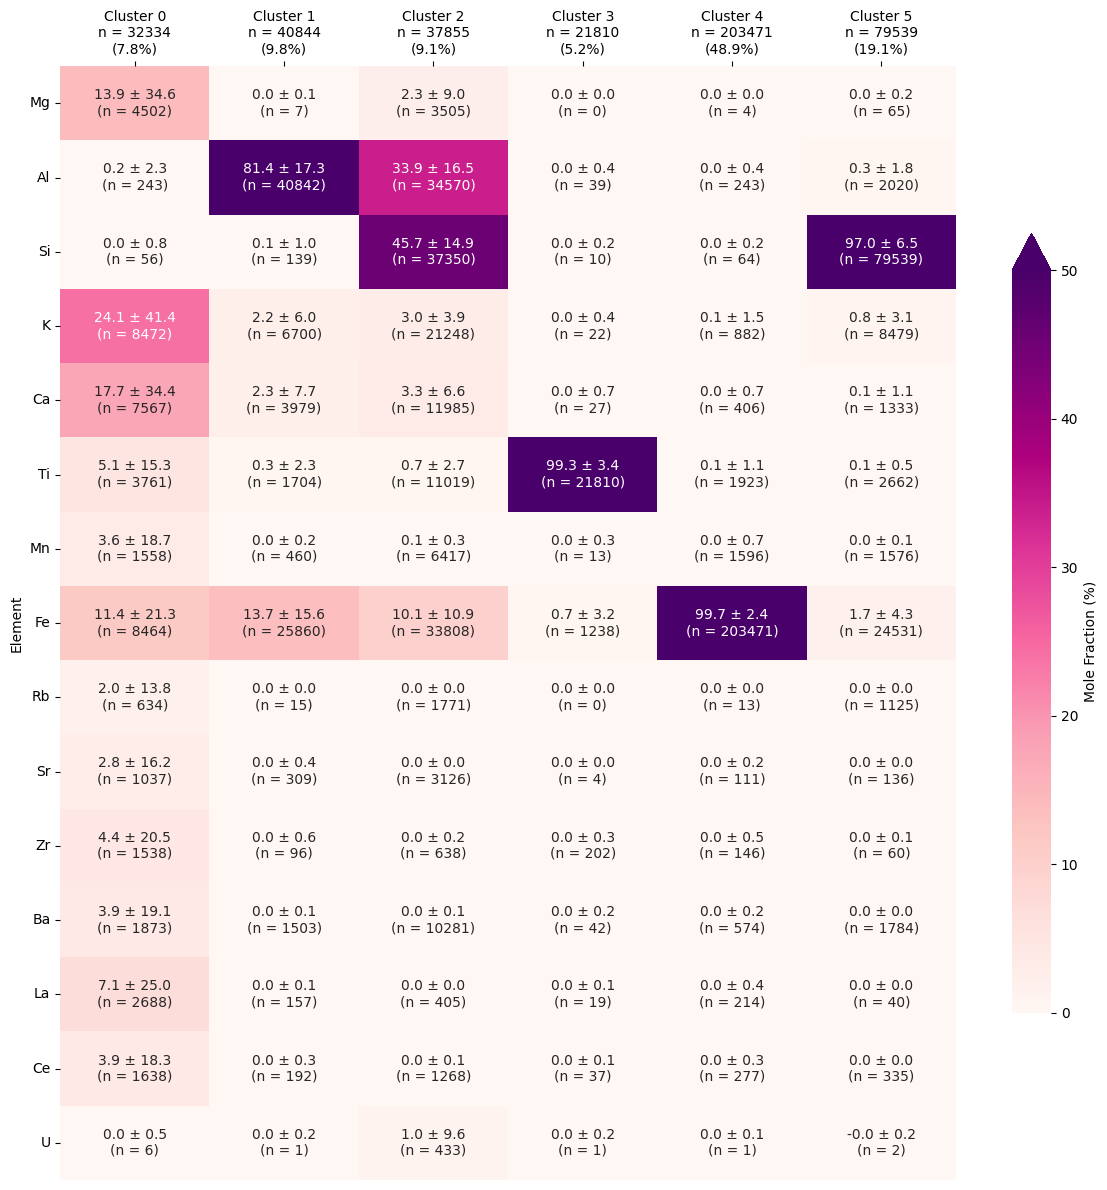

In [7]:

# Plot heatmap
plt.figure(figsize=(12, 12))
ax = sns.heatmap(
    means.T,
    annot=annot.T,
    fmt="",
    cmap='RdPu', vmin=0, vmax=50,
    cbar_kws={'label': 'Mole Fraction (%)', "shrink": 0.7, 'extend': 'max', 'extendrect': False},
    xticklabels=size_clusters_df['Sentence'], yticklabels=elements
)

plt.yticks(rotation=0)
plt.xticks(rotation=0)
ax.xaxis.tick_top()
plt.ylabel('Element')
plt.xlabel('')
plt.tight_layout()
plt.savefig("Figures/cluster_compo_moles.png", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/zk/2_bksjhn0g731cln_7qgt3q00000gn/T/ipykernel_15023/789677682.py:18: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



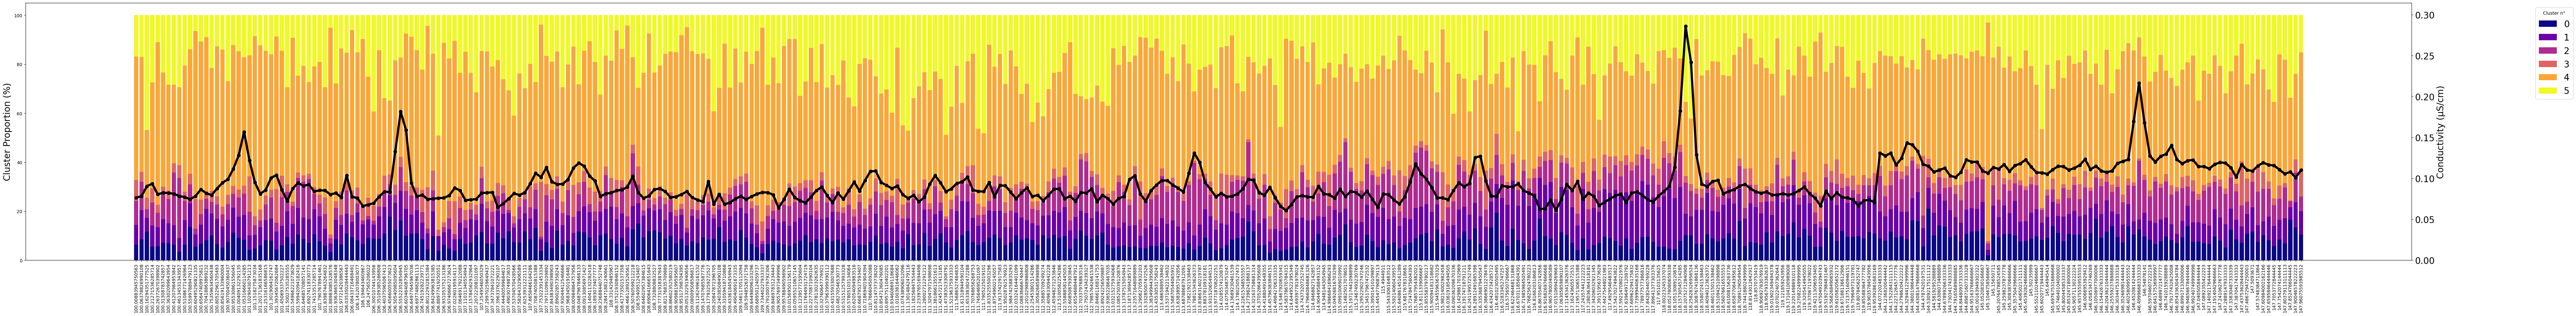

In [76]:
# Calculate the proportion of each cluster per sample
count_df = merged_df.groupby(['Depth', 'Agglomerative Cluster']).size().reset_index(name='Count')

# Calculate the total number of clusters per sample
total_df = merged_df.groupby('Depth').size().reset_index(name='Total')

# Merge the two DataFrames to get the proportion
proportion_df = pd.merge(count_df, total_df, on='Depth')
proportion_df['Proportion'] = 100 * proportion_df['Count'] / proportion_df['Total']

# Prepare the data (pivot so each cluster becomes a column)
stacked_df = proportion_df.pivot(index='Depth', columns='Agglomerative Cluster', values='Proportion').fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(80, 10))

bottom = None  # to stack bars on top of each other
colors = plt.cm.get_cmap('plasma', stacked_df.shape[1])  # choose a colormap with enough distinct colors

for i, cluster in enumerate(stacked_df.columns):
    ax.bar(
        stacked_df.index,
        stacked_df[cluster],
        bottom=bottom,
        label=cluster,
        color=colors(i)
    )
    # Update bottom for next cluster
    bottom = stacked_df[cluster] if bottom is None else bottom + stacked_df[cluster]

# Formatting
ax.set_ylabel("Cluster Proportion (%)", fontsize=20)
ax.set_xticks(range(len(stacked_df.index)))
ax.set_xticklabels(stacked_df.index, rotation=90)
ax.legend(title="Cluster n°", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20)

# add a twin y-axis for the conductivity
ax2 = ax.twinx()
# Compute mean conductivity per sample
cond_df = merged_df.groupby('Depth')['Conductivity'].mean().reindex(stacked_df.index)

# Plot conductivity per sample
ax2.plot(
    cond_df.index,
    cond_df.values,
    color='black',
    marker='o',
    label='Conductivity (µS/cm)',
    markersize=7,
    linewidth=5
)
# Set the y-axis label for conductivity
ax2.set_ylabel('Conductivity (µS/cm)', fontsize=20)
# Set the y-axis limits for conductivity
ax2.set_ylim(0, merged_df['Conductivity'].max() * 1.1)

# # Increase y-ticks fontsize
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.tight_layout()
plt.savefig("Figures/cluster_proportions.png", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
def ternary_plot(dataframe, var1, var2, var3, var4='Cluster'):
    # Rename cluster values to "Cluster X"
    dataframe[var4] = dataframe[var4].apply(lambda x: f"Cluster {x}")

    fig = px.scatter_ternary(
        dataframe,
        a=var1, b=var2, c=var3,
        color=var4,
        color_continuous_scale=px.colors.sequential.Viridis,
        size='Sum',
        size_max=50
    )

    # Update ternary axis titles and styling
    fig.update_ternaries(
        aaxis_title_text=var1, baxis_title_text=var2, caxis_title_text=var3,
        aaxis_title=dict(font_size=20, font_color='black'),
        baxis_title=dict(font_size=20, font_color='black'),
        caxis_title=dict(font_size=20, font_color='black'),
        aaxis_linecolor='black', baxis_linecolor='black', caxis_linecolor='black',
        aaxis_ticks='outside', baxis_ticks='outside', caxis_ticks='outside',
        aaxis_gridcolor='lightgrey', baxis_gridcolor='lightgrey', caxis_gridcolor='lightgrey',
        bgcolor='white'
    )

    fig.update_coloraxes(colorbar_title_font=dict(size=15))

    # Remove legend title and adjust legend position
    fig.update_layout(
        legend=dict(title_text='', x=0.8, y=0.8),
        width=1200,  # Increased width for better visibility
        height=1200,  # Increased height for better visibility
        margin=dict(l=50, r=50, t=50, b=50),  # Added margins
        font=dict(size=16)  # Increased font size for better readability
    )

    # Add reference mineral points
    fig.add_trace(go.Scatterternary(a=[0.47],b=[0.52],c=[0.01],mode="markers",marker=dict(symbol='square', color='blue', size=20), name='Kaolinite'))
    fig.add_trace(go.Scatterternary(a=[0.35],b=[0.55],c=[0.10],mode="markers",marker=dict(symbol='square', color='black', size=20), name='Illite'))
    fig.add_trace(go.Scatterternary(a=[0.25],b=[0.40],c=[0.35],mode="markers",marker=dict(symbol='square', color='orange', size=20), name='Chlorite'))
    fig.add_trace(go.Scatterternary(a=[0.23],b=[0.65],c=[0.12],mode="markers",marker=dict(symbol='cross', color='firebrick', size=20), name='Basaltic glass'))
    fig.add_trace(go.Scatterternary(a=[0.17],b=[0.80],c=[0.03],mode="markers",marker=dict(symbol='cross', color='green', size=20), name='Rhyolitic glass'))

    # Save the figure
    fig.write_image(f"Figures/ternary_plot_{var1}-{var2}-{var3}.png", scale=2)  # Removed dpi argument


In [10]:
#cluster_number = [0,2,3,7]
cluster_number = [1,2,5]  # Specify the cluster number you want to plot

# extract only data for the elements Al, Si, and Fe mole fraction for cluster 1,2,6
data_tern = merged_df[(merged_df['Agglomerative Cluster'].isin(cluster_number)) & (merged_df['Sum'] > 0)].copy()  # Filter for clusters 0, 3, and 8 and Sum > 0
# Select only the relevant columns for the ternary plot
data_tern = data_tern[['Al mole fraction', 'Si mole fraction', 'Fe mole fraction', 'Agglomerative Cluster', 'Sum']]
# Rename columns for clarity in the ternary plot
data_tern.rename(columns={
    'Al mole fraction': 'Al',
    'Si mole fraction': 'Si',
    'Fe mole fraction': 'Fe'
}, inplace=True)
# Ensure the 'Cluster' column is categorical for better color mapping
data_tern['Agglomerative Cluster'] = data_tern['Agglomerative Cluster'].astype('category')
# Ensure the 'Sum' column is numeric for size scaling
data_tern['Sum'] = pd.to_numeric(data_tern['Sum'], errors='coerce')
# Remove rows with NaN values in the ternary plot data
#data_tern.dropna(subset=['Al', 'Si', 'Fe', 'Sum'], inplace=True)

# plot ternary plot of the NP data

ternary_plot(data_tern, 'Al', 'Si', 'Fe', 'Agglomerative Cluster')

In [11]:
# plot a ternary plot of the NP data with the elements La, Ce and Sr
data_tern = merged_df[(merged_df['Agglomerative Cluster'].isin([0])) & (merged_df['Sum'] > 0)].copy()  # Filter for clusters 0 and Sum > 0
# Select only the relevant columns for the ternary plot
data_tern = data_tern[['La mole fraction', 'Ce mole fraction', 'Ca mole fraction', 'Agglomerative Cluster', 'Sum']]
# Rename columns for clarity in the ternary plot
data_tern.rename(columns={
    'La mole fraction': 'La',
    'Ce mole fraction': 'Ce',
    'Ca mole fraction': 'Ca'
}, inplace=True)
# Ensure the 'Cluster' column is categorical for better color mapping
data_tern['Agglomerative Cluster'] = data_tern['Agglomerative Cluster'].astype('category')
# Ensure the 'Sum' column is numeric for size scaling
data_tern['Sum'] = pd.to_numeric(data_tern['Sum'], errors='coerce')
# Remove rows with NaN values in the ternary plot data
#data_tern.dropna(subset=['La', 'Ce', 'Sr', 'Sum'], inplace=True)

# plot ternary plot of the NP data
ternary_plot(data_tern, 'La', 'Ce', 'Ca', 'Agglomerative Cluster')

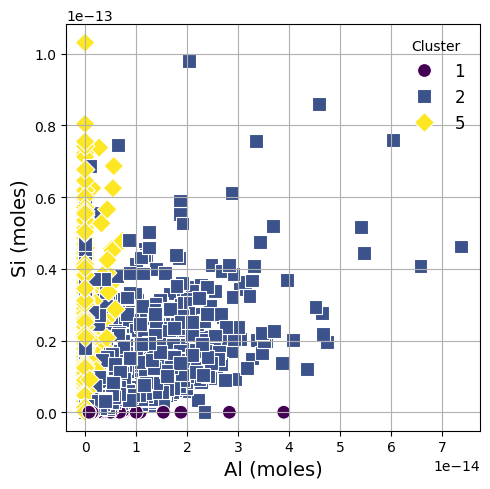

In [12]:
# plot Al vs Si scatter plot for clusters 1,2,6 using the moles
plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=merged_df[merged_df['Agglomerative Cluster'].isin(cluster_number)],
    x='Al moles', y='Si moles',
    hue='Agglomerative Cluster', style='Agglomerative Cluster',
    palette='viridis', markers=['o', 's', 'D'], s=100
)
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Al (moles)', fontsize=14)
plt.ylabel('Si (moles)', fontsize=14)
plt.legend(title='Cluster', fontsize=12, frameon=False)
plt.grid(True)
plt.tight_layout()

#plt.savefig("Figures/Al_Si_scatter.png", dpi=300, bbox_inches='tight')
plt.show()


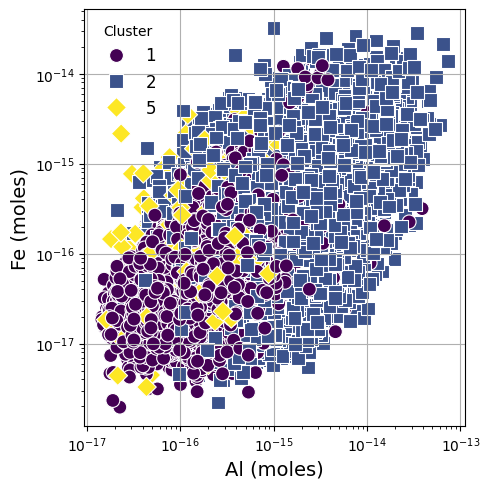

In [13]:
# plot Al vs Fe scatter plot for clusters 1,2,6 using the moles
plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=merged_df[merged_df['Agglomerative Cluster'].isin(cluster_number)],
    x='Al moles', y='Fe moles',
    hue='Agglomerative Cluster', style='Agglomerative Cluster',
    palette='viridis', markers=['o', 's', 'D'], s=100
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Al (moles)', fontsize=14)
plt.ylabel('Fe (moles)', fontsize=14)
plt.legend(title='Cluster', fontsize=12, frameon=False)
plt.grid(True)
plt.tight_layout()

plt.savefig("Figures/Al_Fe_scatter.png", dpi=300, bbox_inches='tight')
plt.show()


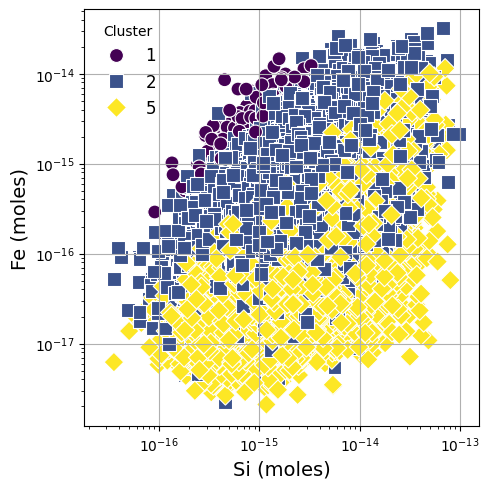

In [14]:
# plot Si vs Fe scatter plot for clusters 1,2,6 using the moles
plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=merged_df[merged_df['Agglomerative Cluster'].isin(cluster_number)],
    x='Si moles', y='Fe moles',
    hue='Agglomerative Cluster', style='Agglomerative Cluster',
    palette='viridis', markers=['o', 's', 'D'], s=100
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Si (moles)', fontsize=14)
plt.ylabel('Fe (moles)', fontsize=14)
plt.legend(title='Cluster', fontsize=12, frameon=False)
plt.grid(True)
plt.tight_layout()

plt.savefig("Figures/Si_Fe_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

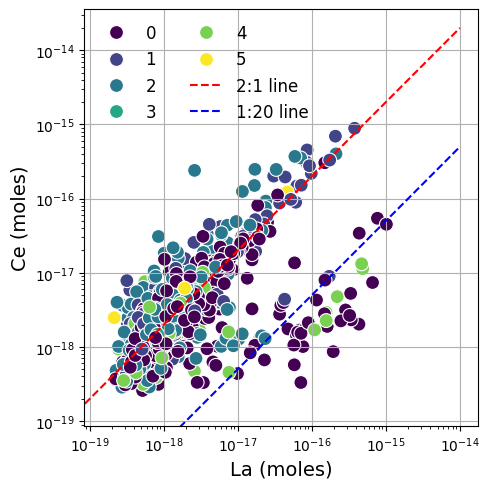

In [15]:
# plot La vs Ce scatter plot for cluster 7 using the moles
plt.figure(figsize=(5, 5))
sns.scatterplot(
    data=merged_df,#[merged_df['Agglomerative Cluster'] == 5],
    x='La moles', y='Ce moles',
    hue='Agglomerative Cluster',# style='Agglomerative Cluster',
    palette='viridis', markers=['o'], s=100
)

# add a 2:1 line to the plot
x = np.linspace(0, 1e-14, 100)
plt.plot(x, x * 2, color='red', linestyle='--', label='2:1 line')
plt.plot(x, x * 0.05, color='blue', linestyle='--', label='1:20 line')


plt.xscale('log')
plt.yscale('log')
#plt.xlim(-1e-16, 0.5e-15)
#plt.ylim(-2e-16, 0.5e-15)
plt.xlabel('La (moles)', fontsize=14)
plt.ylabel('Ce (moles)', fontsize=14)
plt.legend(fontsize=12, frameon=False, ncol=2, loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/La_Ce_scatter.png", dpi=300, bbox_inches='tight')

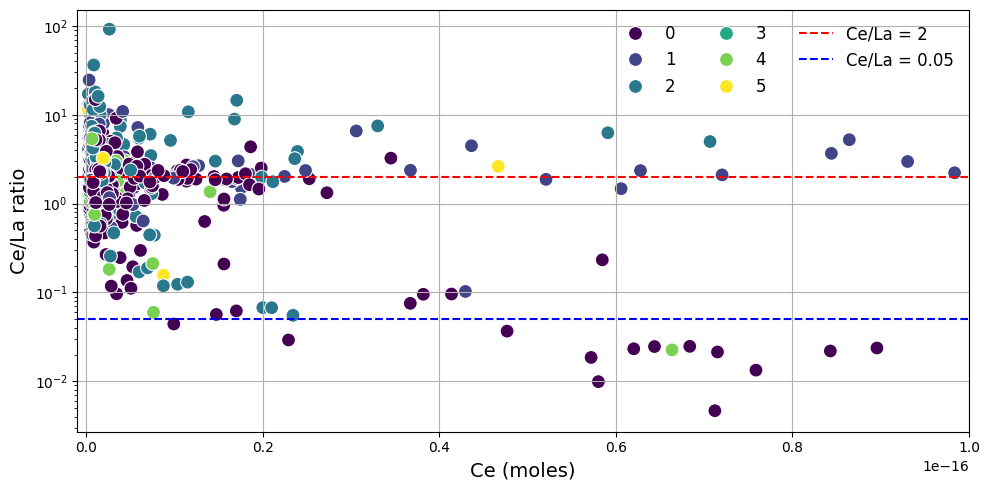

In [16]:
# plot the molar ratio Ce/La vs Ce moles

# calculate the Ce/La ratio
merged_df['Ce/La ratio'] = merged_df['Ce moles'] / merged_df['La moles']

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=merged_df,
    x='La moles', y='Ce/La ratio',
    hue='Agglomerative Cluster',# style='Agglomerative Cluster',
    palette='viridis', markers=['o'], s=100
)

plt.axhline(y=2, color='red', linestyle='--', label='Ce/La = 2')
plt.axhline(y=0.05, color='blue', linestyle='--', label='Ce/La = 0.05')
#plt.xscale('log')
plt.yscale('log')
plt.xlim(-1e-18, 1e-16)  # Set x-axis limit to avoid extreme values
plt.xlabel('Ce (moles)', fontsize=14)
plt.ylabel('Ce/La ratio', fontsize=14)
plt.legend(fontsize=12, frameon=False, ncol=3)#, loc='upper left')
plt.grid(True)
plt.tight_layout()
#plt.savefig("Figures/Ce_CeLa_ratio_scatter.png", dpi=300, bbox_inches='tight')

In [54]:
df_kaolinite = merged_df[(merged_df['Al'] > 0) & (merged_df['Si'] > 0) & (merged_df['Fe'] > 0)].copy()
df_kaolinite['Sum'] = df_kaolinite['Al'] + df_kaolinite['Si'] + df_kaolinite['Fe'] #total mass in ag

# convert to volume assuming density of kaolinite is 2.6 g/cm^3 and 1ag = 1e-18g
df_kaolinite['Volume'] = df_kaolinite['Sum'] * 1e-18 / 2.6e-21  # in nm^3

# convert to equivalent radius in nm
df_kaolinite['Size'] = 2 * (3 * df_kaolinite['Volume'] / (4 * np.pi)) ** (1/3)  # in nm
df_kaolinite

,Mg,Al,Si,K,Ca,Ti,Mn,Fe,Rb,Sr,...,La mole fraction,Ce mole fraction,U mole fraction,Agglomerative Cluster,Ce/La ratio,Al/Si ratio,Si/Fe ratio,Al/Fe ratio,Volume,Size
11,0.0,56703.161,41780.729,9725.8827,0.000,0.0000,613.27401,33390.3280,0.0,0.0,...,0.0,0.0,0.0,2,NaN,1.412640,2.488085,3.514769,5.072085e+07,459.264252
13,0.0,26896.066,18487.009,0.0000,0.000,0.0000,0.00000,8030.5981,0.0,0.0,...,0.0,0.0,0.0,2,NaN,1.514337,4.577503,6.931880,2.054372e+07,339.802699
22,0.0,178863.300,87213.292,0.0000,66329.016,0.0000,0.00000,3925.4092,0.0,0.0,...,0.0,0.0,0.0,2,NaN,2.134710,44.178159,94.307550,1.038469e+08,583.174247
45,0.0,51180.888,32083.983,0.0000,0.000,0.0000,282.03273,39033.9140,0.0,0.0,...,0.0,0.0,0.0,2,NaN,1.660427,1.634391,2.713788,4.703799e+07,447.868025
66,0.0,41821.604,57477.333,0.0000,10097.650,0.0000,0.00000,25723.5560,0.0,0.0,...,0.0,0.0,0.0,2,NaN,0.757363,4.442991,3.364959,4.808557e+07,451.168456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415776,0.0,14003.458,19057.199,0.0000,0.000,0.0000,0.00000,4219.6675,0.0,0.0,...,0.0,0.0,0.0,2,NaN,0.764850,8.980297,6.868584,1.433859e+07,301.418038
415826,0.0,68075.468,87481.150,0.0000,11355.521,1990.8919,0.00000,14679.5190,0.0,0.0,...,0.0,0.0,0.0,2,NaN,0.809984,11.849841,9.598182,6.547544e+07,500.065157
415828,0.0,12391.858,50892.801,0.0000,0.000,35699.1360,0.00000,33853.1800,0.0,0.0,...,0.0,0.0,0.0,2,NaN,0.253443,2.989281,0.757612,3.736071e+07,414.768236
415836,0.0,103854.930,89383.824,12749.2900,0.000,0.0000,0.00000,65280.6790,0.0,0.0,...,0.0,0.0,0.0,2,NaN,1.209396,2.722602,3.292703,9.943055e+07,574.787182


In [57]:
df_kaolinite['Al/Si ratio'] = df_kaolinite['Al moles'] / df_kaolinite['Si moles']
df_kaolinite['Si/Fe ratio'] = df_kaolinite['Si moles'] / df_kaolinite['Fe moles']
df_kaolinite['Al/Fe ratio'] = df_kaolinite['Al moles'] / df_kaolinite['Fe moles']

/var/folders/zk/2_bksjhn0g731cln_7qgt3q00000gn/T/ipykernel_15023/4111811171.py:3: UserWarning:


The markers list has fewer values (1) than needed (6) and will cycle, which may produce an uninterpretable plot.



Mean Al/Si ratio: 0.92 ± 0.65


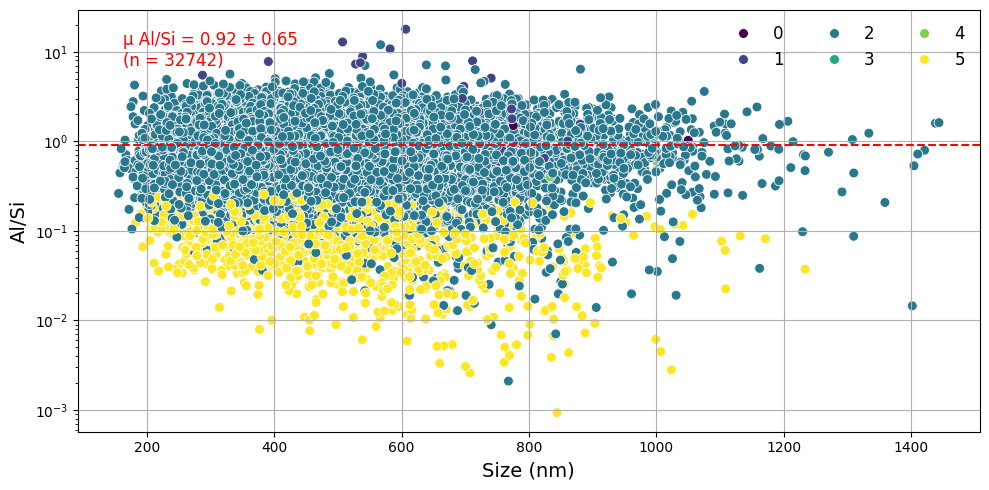

In [72]:
def plot_ratio(df, num, den):
    plt.figure(figsize=(10, 5))
    sns.scatterplot(
        data=df,
        x='Size', y=f'{num}/{den} ratio',
        hue='Agglomerative Cluster', style='Agglomerative Cluster',
        palette='viridis', markers=['o'], s=50
    )

    # Calculate the mean and std ratio
    mean_ratio = df[f'{num}/{den} ratio'].mean()
    std_ratio = df[f'{num}/{den} ratio'].std()

    print(f"Mean {num}/{den} ratio: {mean_ratio:.2f} ± {std_ratio:.2f}")

    plt.axhline(y=mean_ratio, color='red', linestyle='--')#, label=f"µ {num}/{den} = {mean_al_si_ratio:.2f} ± {std_al_si_ratio:.2f} (n = {len(df[f'{num}/{den} ratio'])})")
    plt.annotate(f"µ {num}/{den} = {mean_ratio:.2f} ± {std_ratio:.2f}\n(n = {len(df[f'{num}/{den} ratio'])})", xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12, color='red', ha='left', va='top')

    plt.yscale('log')
    plt.xlabel('Size (nm)', fontsize=14)
    plt.ylabel(f'{num}/{den}', fontsize=14)
    plt.legend(fontsize=12, frameon=False, ncol=3)
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(f"Figures/{num}_{den}_ratio_scatter.png", dpi=300, bbox_inches='tight')
    plt.show()

# Call the function
plot_ratio(df_kaolinite, 'Al', 'Si')


/var/folders/zk/2_bksjhn0g731cln_7qgt3q00000gn/T/ipykernel_15023/4111811171.py:3: UserWarning:


The markers list has fewer values (1) than needed (6) and will cycle, which may produce an uninterpretable plot.



Mean Si/Fe ratio: 15.45 ± 27.16


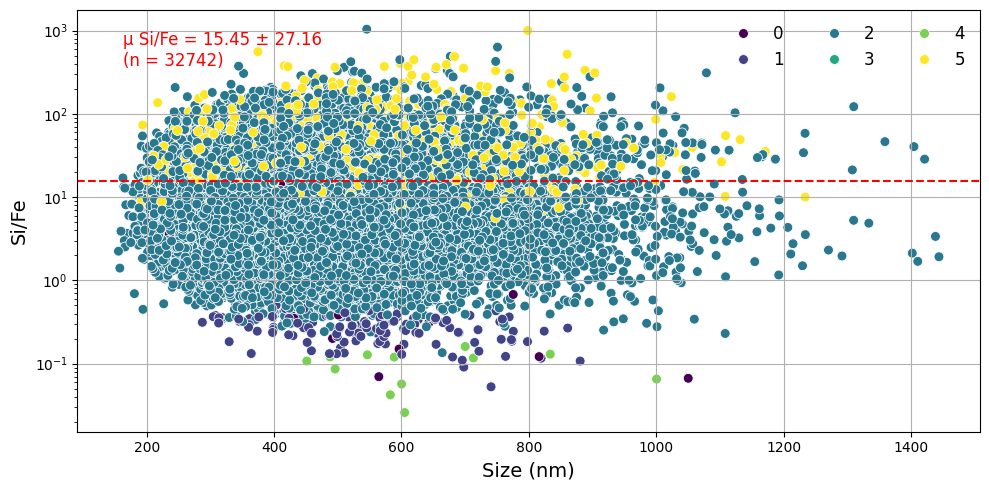

In [73]:
# plot the molar ratio Si/Fe vs Si moles
plot_ratio(df_kaolinite, 'Si', 'Fe')


/var/folders/zk/2_bksjhn0g731cln_7qgt3q00000gn/T/ipykernel_15023/4111811171.py:3: UserWarning:


The markers list has fewer values (1) than needed (6) and will cycle, which may produce an uninterpretable plot.



Mean Al/Fe ratio: 10.80 ± 18.26


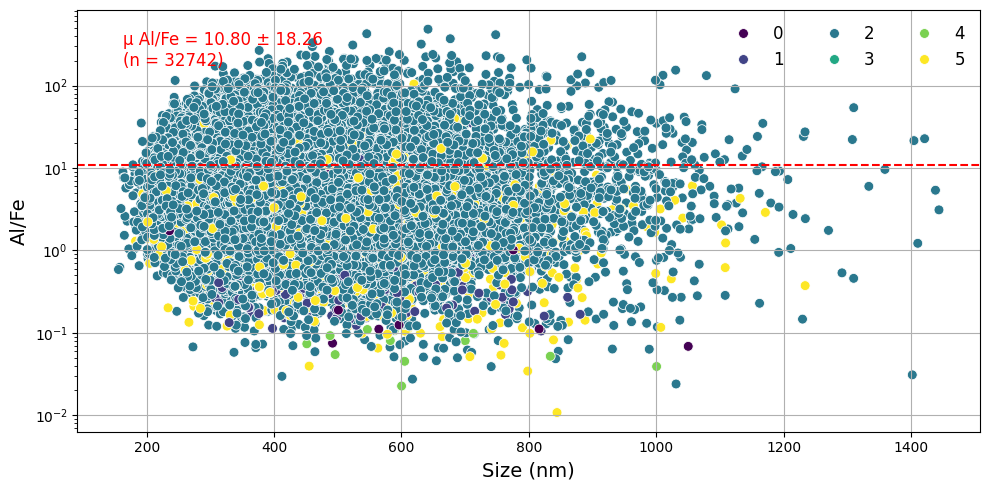

In [74]:
# plot the molar ratio Al/Fe vs Al moles
plot_ratio(df_kaolinite, 'Al', 'Fe')